# 건축물 허가, 착공, 준공 소요기간

2023년 준공 건축물 대상


In [45]:
import pandas as pd

pd.options.display.unicode.east_asian_width = True

file_path = "input/23년 신축 준공 건축물 rowData_전국_240911안.xlsx"

columns_to_read = [
    "시도코드",
    "시군구코드",
    "허가번호pk",
    "대지위치",
    "허가일자",
    "착공일자",
    "사용승인일자",
    "세부용도코드",
    "대분류용도코드",
    "면적",
]
dtype_dict = {col: "str" for col in columns_to_read if col != "면적"}
dtype_dict["면적"] = "float64"
# print(dtype_dict)

df = pd.read_excel(
    file_path,
    sheet_name="rowData",
    usecols=columns_to_read,
    dtype=dtype_dict,
)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77323 entries, 0 to 77322
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   시도코드     77323 non-null  object 
 1   시군구코드    77323 non-null  object 
 2   허가번호pk   77323 non-null  object 
 3   대지위치     77323 non-null  object 
 4   허가일자     77311 non-null  object 
 5   착공일자     76052 non-null  object 
 6   사용승인일자   77323 non-null  object 
 7   세부용도코드   77323 non-null  object 
 8   대분류용도코드  77323 non-null  object 
 9   면적       77323 non-null  float64
dtypes: float64(1), object(9)
memory usage: 5.9+ MB


In [46]:
df.head()

,시도코드,시군구코드,허가번호pk,대지위치,허가일자,착공일자,사용승인일자,세부용도코드,대분류용도코드,면적
0,26,26380,26380-100079721,부산광역시 사하구 장림동 316-8,20190411,20190920,20230707,03999,03,7152.67
1,26,26440,26440-100059833,부산광역시 강서구 눌차동 797-31,20160527,20160601,20230821,03001,03,73.44
2,26,26710,26710-100054931,부산광역시 기장군 정관읍 매학리 143-20,20150730,20150902,20230501,17999,17,1317.22
3,26,26710,26710-100054932,부산광역시 기장군 정관읍 매학리 143-19,20150730,20150902,20231016,17301,17,948.00
4,26,26710,26710-100054932,부산광역시 기장군 정관읍 매학리 143-19,20150730,20150902,20231016,17301,17,66.00


In [47]:
date_columns = ["허가일자", "착공일자", "사용승인일자"]


def is_valid_date(val):
    # 8자리 숫자 스트링인지 확인
    if type(val) is not str:
        return False

    if not val.isdigit():
        return False

    if not len(val) == 8:
        return False

    return True


df2 = df.copy()

# 각 날짜 컬럼에 대해 텍스트를 날짜로 변환하면서 예외 처리 (에러 발생 시 NaT로 변환)
# 원본 유지, 변환된 컬럼 생성
for col in date_columns:
    # 8자리 숫자가 아닌 경우 null(NA) 처리
    df2[f"{col}_valid"] = df2[col].apply(lambda x: x if is_valid_date(x) else pd.NA)
    # 8자리 숫자인 값에 대해서만 날짜 변환 (null 값은 NaT로 남음)
    df2[f"{col}_date"] = pd.to_datetime(
        df2[f"{col}_valid"], errors="coerce", format=r"%Y%m%d"
    )

df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77323 entries, 0 to 77322
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   시도코드          77323 non-null  object        
 1   시군구코드         77323 non-null  object        
 2   허가번호pk        77323 non-null  object        
 3   대지위치          77323 non-null  object        
 4   허가일자          77311 non-null  object        
 5   착공일자          76052 non-null  object        
 6   사용승인일자        77323 non-null  object        
 7   세부용도코드        77323 non-null  object        
 8   대분류용도코드       77323 non-null  object        
 9   면적            77323 non-null  float64       
 10  허가일자_valid    77311 non-null  object        
 11  허가일자_date     77311 non-null  datetime64[ns]
 12  착공일자_valid    76051 non-null  object        
 13  착공일자_date     76051 non-null  datetime64[ns]
 14  사용승인일자_valid  77323 non-null  object        
 15  사용승인일자_date   77323 non-null  dateti

In [48]:
df2[~df2["착공일자"].isna() & (df2["착공일자"] != df2["착공일자_valid"])].head()


,시도코드,시군구코드,허가번호pk,대지위치,허가일자,착공일자,사용승인일자,세부용도코드,대분류용도코드,면적,허가일자_valid,허가일자_date,착공일자_valid,착공일자_date,사용승인일자_valid,사용승인일자_date
76962,11,11320,11320-100069025,서울특별시 도봉구 도봉동 559-22,20210222,2021042,20230926,02002,02,1299.78,20210222,2021-02-22,<NA>,NaT,20230926,2023-09-26


In [58]:
df3 = df2.copy()

# 날짜 차이를 계산하고 일 수로 변환하여 새 컬럼에 저장
df3["허가_착공_소요일"] = (df3["착공일자_date"] - df3["허가일자_date"]).dt.days.astype(
    "Int64"
)
df3["착공_사용승인_소요일"] = (
    df3["사용승인일자_date"] - df3["착공일자_date"]
).dt.days.astype("Int64")
df3["허가_사용승인_소요일"] = (
    df3["사용승인일자_date"] - df3["허가일자_date"]
).dt.days.astype("Int64")

df3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77323 entries, 0 to 77322
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   시도코드          77323 non-null  object        
 1   시군구코드         77323 non-null  object        
 2   허가번호pk        77323 non-null  object        
 3   대지위치          77323 non-null  object        
 4   허가일자          77311 non-null  object        
 5   착공일자          76052 non-null  object        
 6   사용승인일자        77323 non-null  object        
 7   세부용도코드        77323 non-null  object        
 8   대분류용도코드       77323 non-null  object        
 9   면적            77323 non-null  float64       
 10  허가일자_valid    77311 non-null  object        
 11  허가일자_date     77311 non-null  datetime64[ns]
 12  착공일자_valid    76051 non-null  object        
 13  착공일자_date     76051 non-null  datetime64[ns]
 14  사용승인일자_valid  77323 non-null  object        
 15  사용승인일자_date   77323 non-null  dateti

In [59]:
# 결과 확인
df3[
    [
        "허가번호pk",
        "대지위치",
        "허가일자_date",
        "착공일자_date",
        "사용승인일자_date",
        "허가_착공_소요일",
        "착공_사용승인_소요일",
        "허가_사용승인_소요일",
    ]
].head()


,허가번호pk,대지위치,허가일자_date,착공일자_date,사용승인일자_date,허가_착공_소요일,착공_사용승인_소요일,허가_사용승인_소요일
0,26380-100079721,부산광역시 사하구 장림동 316-8,2019-04-11,2019-09-20,2023-07-07,162,1386,1548
1,26440-100059833,부산광역시 강서구 눌차동 797-31,2016-05-27,2016-06-01,2023-08-21,5,2637,2642
2,26710-100054931,부산광역시 기장군 정관읍 매학리 143-20,2015-07-30,2015-09-02,2023-05-01,34,2798,2832
3,26710-100054932,부산광역시 기장군 정관읍 매학리 143-19,2015-07-30,2015-09-02,2023-10-16,34,2966,3000
4,26710-100054932,부산광역시 기장군 정관읍 매학리 143-19,2015-07-30,2015-09-02,2023-10-16,34,2966,3000


In [64]:
# 결과 확인
df3[
    [
        "허가_착공_소요일",
        "착공_사용승인_소요일",
        "허가_사용승인_소요일",
    ]
].describe()


,허가_착공_소요일,착공_사용승인_소요일,허가_사용승인_소요일
count,76050.0,76051.0,77311.0
mean,163.59783,533.5918,703.712175
std,456.033968,727.642722,948.722228
min,-340.0,0.0,1.0
25%,16.0,168.0,223.0
50%,50.0,281.0,388.0
75%,147.0,592.0,819.0
max,14972.0,11935.0,19037.0


In [69]:
df3[
    [
        "허가번호pk",
        "대지위치",
        "허가일자_date",
        "착공일자_date",
        "사용승인일자_date",
        "허가_착공_소요일",
        "착공_사용승인_소요일",
        "허가_사용승인_소요일",
    ]
].nsmallest(5, "허가_착공_소요일")


,허가번호pk,대지위치,허가일자_date,착공일자_date,사용승인일자_date,허가_착공_소요일,착공_사용승인_소요일,허가_사용승인_소요일
23433,41480-1000000000000000085981,경기도 파주시 월롱면 능산리 211-5,2023-10-24,2022-11-18,2023-10-27,-340,343,3
51094,47820-100098834,경상북도 청도군 청도읍 원정리 490-4,2022-02-22,2021-04-16,2023-10-27,-312,924,612
3430,28710-1000000000000000204905,인천광역시 강화군 하점면 삼거리 929-1,2022-12-29,2022-12-29,2023-05-08,0,130,130
3431,28710-1000000000000000204905,인천광역시 강화군 하점면 삼거리 929-1,2022-12-29,2022-12-29,2023-05-08,0,130,130
3464,28710-100168623,인천광역시 강화군 선원면 연리 421-33,2021-11-05,2021-11-05,2023-05-12,0,553,553


In [70]:
df3[
    [
        "허가번호pk",
        "대지위치",
        "허가일자_date",
        "착공일자_date",
        "사용승인일자_date",
        "허가_착공_소요일",
        "착공_사용승인_소요일",
        "허가_사용승인_소요일",
    ]
].nsmallest(5, "착공_사용승인_소요일")


,허가번호pk,대지위치,허가일자_date,착공일자_date,사용승인일자_date,허가_착공_소요일,착공_사용승인_소요일,허가_사용승인_소요일
15155,41830-100379522,경기도 양평군 개군면 상자포리 119-2,2022-02-15,2023-02-10,2023-02-10,360,0,360
42173,44800-1000000000000000396723,충청남도 홍성군 결성면 성곡리 373,2023-10-26,2023-10-26,2023-10-27,0,1,1
43496,46780-1000000000000000391146,전라남도 보성군 벌교읍 장암리 0,2023-10-18,2023-10-18,2023-10-19,0,1,1
43543,46770-1000000000000000369351,전라남도 고흥군 포두면 상대리 8-2,2023-09-08,2023-09-14,2023-09-15,6,1,7
43544,46770-1000000000000000369351,전라남도 고흥군 포두면 상대리 8-2,2023-09-08,2023-09-14,2023-09-15,6,1,7


In [71]:
df3[
    [
        "허가번호pk",
        "대지위치",
        "허가일자_date",
        "착공일자_date",
        "사용승인일자_date",
        "허가_착공_소요일",
        "착공_사용승인_소요일",
        "허가_사용승인_소요일",
    ]
].nsmallest(5, "허가_사용승인_소요일")


,허가번호pk,대지위치,허가일자_date,착공일자_date,사용승인일자_date,허가_착공_소요일,착공_사용승인_소요일,허가_사용승인_소요일
42173,44800-1000000000000000396723,충청남도 홍성군 결성면 성곡리 373,2023-10-26,2023-10-26,2023-10-27,0,1,1
43496,46780-1000000000000000391146,전라남도 보성군 벌교읍 장암리 0,2023-10-18,2023-10-18,2023-10-19,0,1,1
55258,47290-1000000000000000260791,경상북도 경산시 압량읍 부적리 70-12,2023-03-29,2023-03-30,2023-03-31,1,1,2
23433,41480-1000000000000000085981,경기도 파주시 월롱면 능산리 211-5,2023-10-24,2022-11-18,2023-10-27,-340,343,3
72102,52720-1000000000000000347177,전북특별자치도 진안군 동향면 능금리 2078,2023-08-01,2023-08-01,2023-08-04,0,3,3


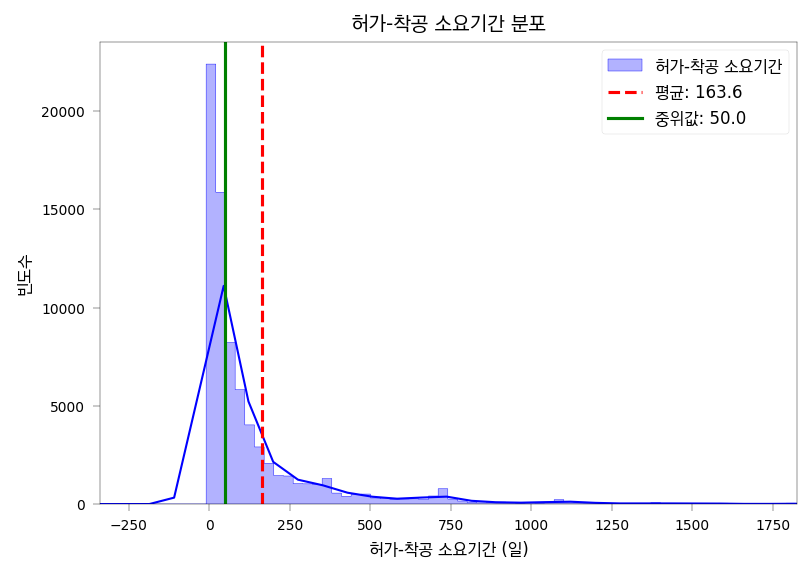

<Figure size 900x600 with 0 Axes>

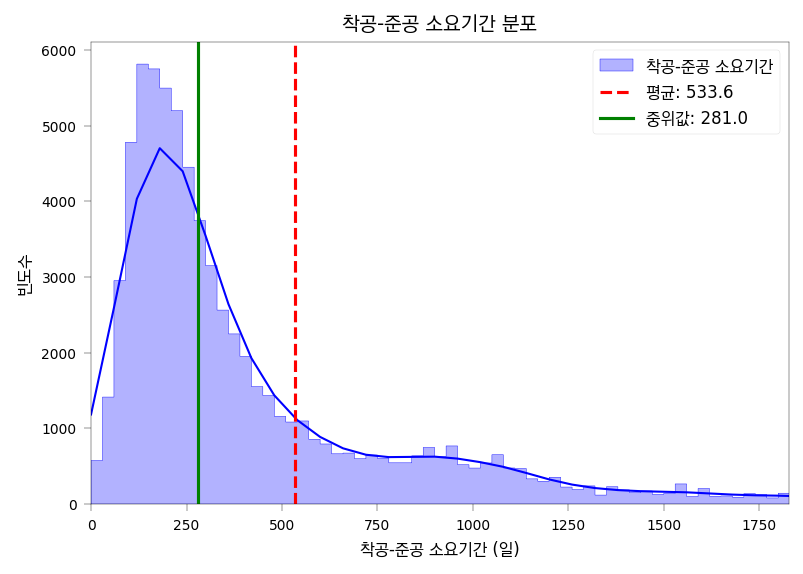

<Figure size 900x600 with 0 Axes>

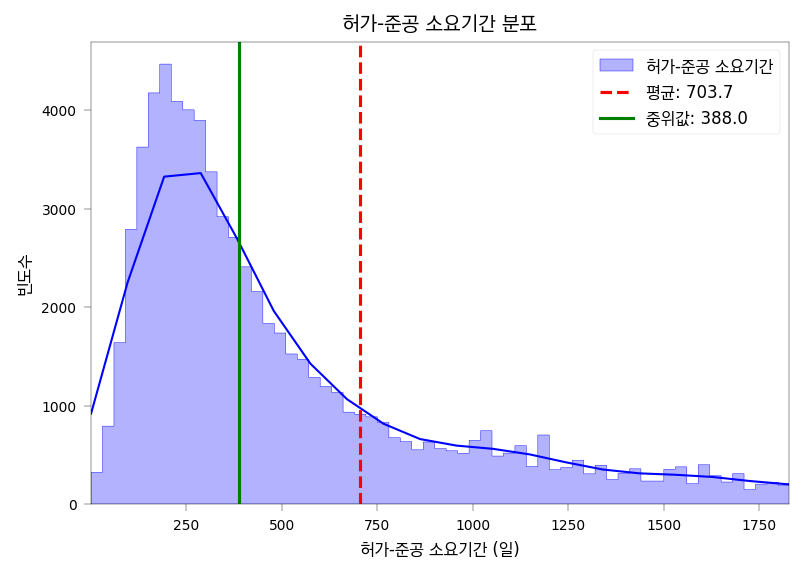

<Figure size 900x600 with 0 Axes>

In [119]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 플롯 스타일 설정
plt.style.use("./auri.mplstyle")

# Create a new directory for saving the figure
output_dir = Path("output/buildingstock/duration/")
output_dir.mkdir(exist_ok=True)

# 소요일 컬럼들 리스트 (분포를 그릴 데이터)
duration_columns = ["허가_착공_소요일", "착공_사용승인_소요일", "허가_사용승인_소요일"]
duration_names = ["허가-착공 소요기간", "착공-준공 소요기간", "허가-준공 소요기간"]

# 각 소요일에 대해 히스토그램, kde, 평균, 중위값을 플롯
for col, name_ in zip(duration_columns, duration_names):
    plt.figure()

    # 히스토그램과 KDE 플롯
    sns.histplot(
        df3[col].dropna(),
        element="step",
        kde=True,
        # kde_kws={"bw_adjust": 1},
        line_kws={
            "marker": " ",
            "linewidth": 1,
        },
        color="blue",
        alpha=0.3,
        binwidth=30,
        label=f"{name_}",
    )

    # 평균과 중위값 계산
    mean_val = df3[col].mean()
    median_val = df3[col].median()

    # 평균선 추가
    plt.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=1.5,
        marker=" ",
        label=f"평균: {mean_val:.1f}",
    )

    # 중위값 추가
    plt.axvline(
        median_val,
        color="green",
        linestyle="-",
        linewidth=1.5,
        marker=" ",
        label=f"중위값: {median_val:.1f}",
    )

    # 범위 설정
    plt.xlim(df3[col].min(), 365.24 * 5)

    # 제목 및 레이블
    plt.title(f"{name_} 분포")
    plt.xlabel(f"{name_} (일)")
    plt.ylabel("빈도수")
    plt.legend()

    # save
    # 그래프가 show()로 표시된 후에는 이미지가 초기화되기 때문에, 먼저 저장한 뒤에 화면에 표시하는 것이 필요합니다.
    plt.savefig(f"{output_dir / name_}.svg")
    plt.savefig(f"{output_dir / name_}.png")

    # 플롯 보여주기
    plt.show()
